### i. Intro

Dataset : https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product

         : Train Path
                Total Data - def_front : 3758 | ok_front : 2875
           Test Path
                Total Data - def_front : 453  | ok_front : 262

Problem yang hendak diselesaikan :

Cacat pengecoran (seperti lubang udara, gerinda, cacat penyusutan, dll) adalah masalah utama di industri logam. Semua perusahaan memiliki departemen inspeksi kualitas, namun prosesnya masih dilakukan secara manual.
Akibatnya, inspeksi lambat & tidak konsisten, akurasi tidak bisa optimal, karena produk cacat bisa lolos ke pelanggan/ produk terbuang sia-sia dan berpotensi menyebabkan penolakan orderan seluruh pesanan yang menyebabkan kerugian besar bagi perusahaan.
Oleh karena itu menggunakan ai bisa membantu dalam mengidentifikasi produk cacat sehingga inspeksi lebih cepat,konsisten dan akurat (efisien)

Objective : 

Menggunakan computer vision model yang bisa membantu dalam mengidentifikasi produk cacat sehingga inspeksi lebih cepat,konsisten dan akurat (efisien).

User/pengguna yang akan menggunakan aplikasi:

Yang umumnya akan menggunakan aplikasi dari ai computer vision model secara langsung untuk identifikasi produk defect atau ok biasanya adalah mereka di lini produksi seperti, Quality Control(QC) Inspector/operator,Quality Assurance (QA) Manager, Plant Manager,Teknisi Maintenance dll




### ii. Import Libraries

In [6]:
# Import libraries

import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input
from tensorflow.keras.utils import plot_model


from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version
print(tf.__version__)

2.18.0


### iii. Data Loading

Dataset yang didapatkan dari kaggle tersimpan dalam casting_data/casting_data dan di dalamnya sudah ada sub-folder untuk kategori masing-masing test dan train

In [9]:
main_path = './casting_data/casting_data'
train_path = os.path.join(main_path, 'train')
test_path = os.path.join(main_path, 'test')

### iv. Exploratory Data Analysis (EDA)

Dalam EDA akan dilakukan analisa untuk :
- Distribusi perkelas (binary : defect & ok)
- Gembar per-kelas (Ciri-ciri umum gambar)
- Image size
- Image Channel Check
- Pixel Intensity Distribution
- Visual Inspection


In [3]:
# Check how many data in `train_path` and `test_path`

def check_path(path):
  labels = os.listdir(path)
  for label in labels:
    num_data = len(os.listdir(os.path.join(path, label)))
    print(f'Total Data - {label} : {num_data}')

print('Train Path')
check_path(train_path)
print('')

print('Test Path')
check_path(test_path)
print('')

Train Path
Total Data - def_front : 3758
Total Data - ok_front : 2875

Test Path
Total Data - def_front : 453
Total Data - ok_front : 262



In [ ]:
# visualisasi distribusi kelas TRAIN

def plot_class_distribution(path):

    classes = os.listdir(path)
    counts = []

    for cls in classes:
        counts.append(len(os.listdir(os.path.join(path, cls))))

    plt.bar(classes, counts)
    plt.title("Class Distribution")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(train_path)

In [ ]:
# visualisasi distribusi kelas Test

def plot_class_distribution(path):

    classes = os.listdir(path)
    counts = []

    for cls in classes:
        counts.append(len(os.listdir(os.path.join(path, cls))))

    plt.bar(classes, counts)
    plt.title("Class Distribution")
    plt.ylabel("Number of Images")
    plt.show()

plot_class_distribution(test_path)

In [4]:
# Function to visualize the first 5 images from each class

def plot_images(path):
  labels = os.listdir(path)
  for label in labels:
    folder_path = os.path.join(path, label)
    fig = plt.figure(figsize=(20, 20))
    columns = 3
    rows = 1
    print('Class : ', label)
    images = os.listdir(folder_path)
    for index in range(1, columns*rows +1):
        fig.add_subplot(rows, columns, index)
        image = plt.imread(os.path.join(folder_path, images[index]))
        plt.imshow(image)
        plt.axis("off")
    plt.show()

Class :  def_front


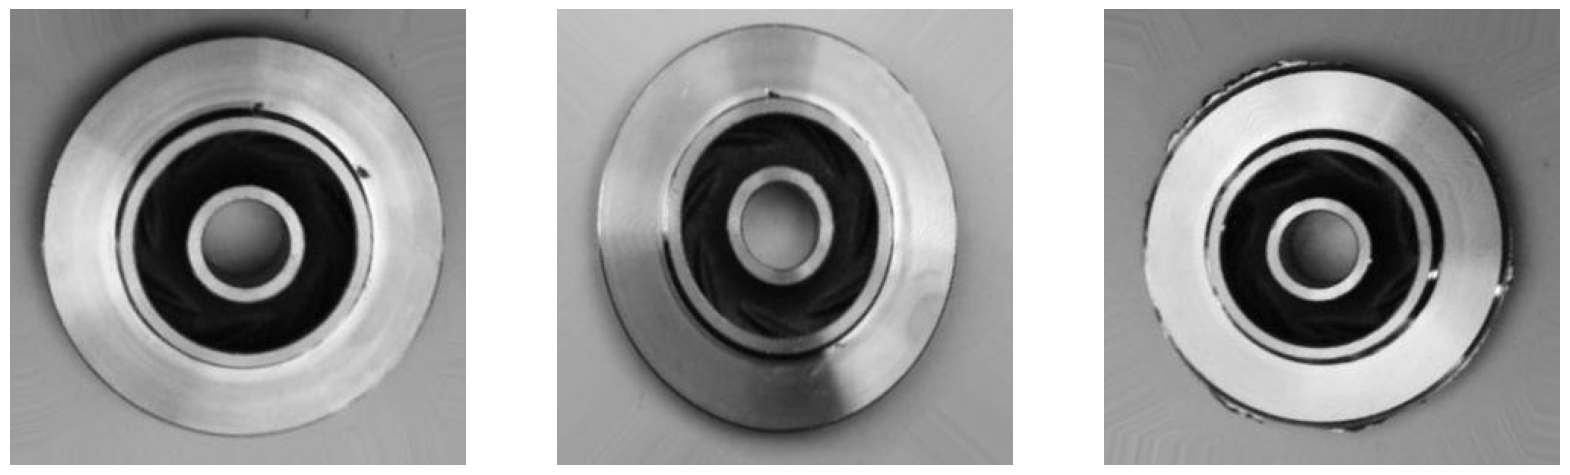

Class :  ok_front


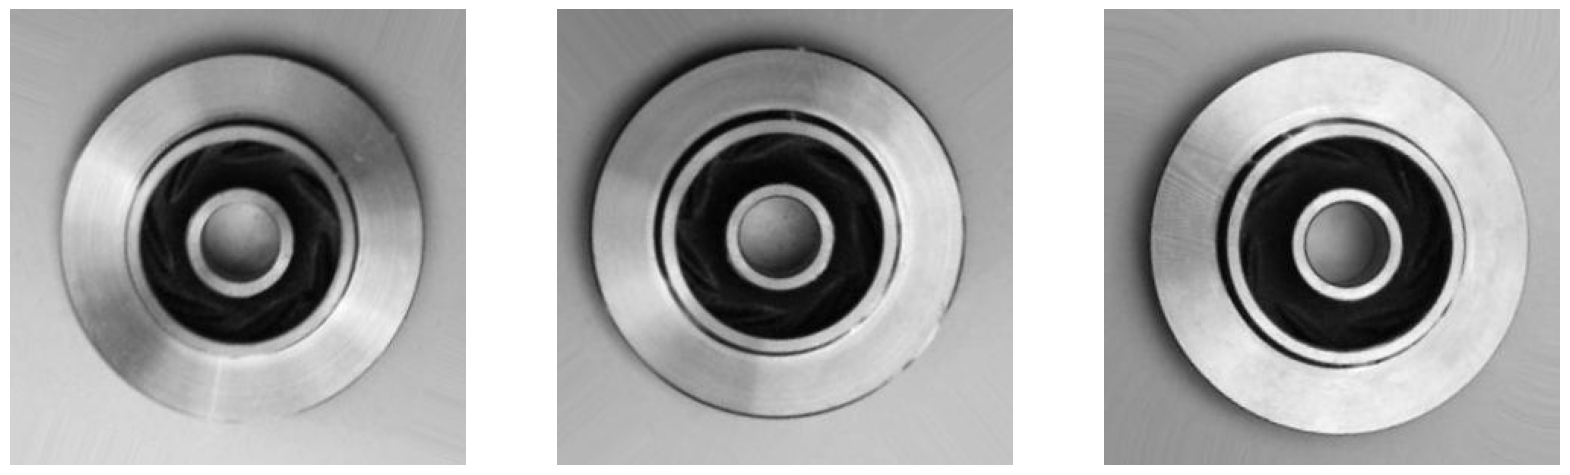

In [16]:
# Visualization of train_path

plot_images(train_path)

1. Kelas Defect (def_front)

Ciri-ciri visual:

Terdapat ketidaksempurnaan bentuk lingkaran (tidak simetris)

Muncul goresan atau area gelap pada permukaan

Ada bagian yang terlihat aus / tidak rata

Pada beberapa sampel terlihat deformasi atau ketidakteraturan tekstur

Interpretasi:
Ciri-ciri tersebut menunjukkan adanya kerusakan fisik pada komponen, khususnya pada bagian permukaan impeller.

2. Kelas Normal (ok_front)

Ciri-ciri visual:

Bentuk lingkaran simetris dan konsisten

Permukaan terlihat halus dan bersih

Tidak terdapat goresan atau cacat yang signifikan

Warna dan tekstur relatif seragam

Interpretasi:
Menunjukkan kondisi impeller yang masih baik dan layak digunakan.

In [ ]:
# Pengecekan ukuran gambar dataset memastikan apakah konsisten atau tidak untuk TRAIN
from PIL import Image
import os

def check_image_size(path):

    sizes = set()

    labels = os.listdir(path)

    for label in labels:
        folder = os.path.join(path,label)

        for img in os.listdir(folder)[:50]:   # cek sebagian
            image = Image.open(os.path.join(folder,img))
            sizes.add(image.size)

    print("Unique image sizes:", sizes)

check_image_size(train_path)

Unique image sizes: {(300, 300)}


In [19]:
# Mengecek apakah gambar RGB atau Grayscale
import cv2

def check_channels(path):

    labels = os.listdir(path)

    for label in labels:
        folder = os.path.join(path,label)

        img = os.listdir(folder)[0]
        image = cv2.imread(os.path.join(folder,img))

        print(label, "shape:", image.shape)

check_channels(train_path)

def_front shape: (300, 300, 3)
ok_front shape: (300, 300, 3)


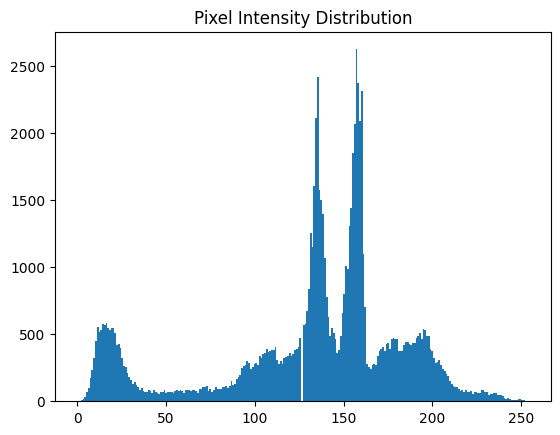

In [20]:
# Visualisasi Distribusi Histogram Pixel

import cv2
import matplotlib.pyplot as plt

img_path = os.path.join(train_path, 'def_front', os.listdir(os.path.join(train_path,'def_front'))[0])

img = cv2.imread(img_path,0)

plt.hist(img.ravel(), bins=256)
plt.title("Pixel Intensity Distribution")
plt.show()

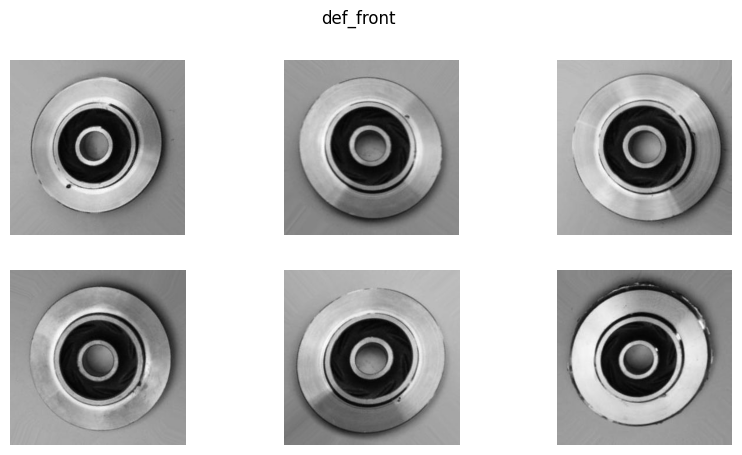

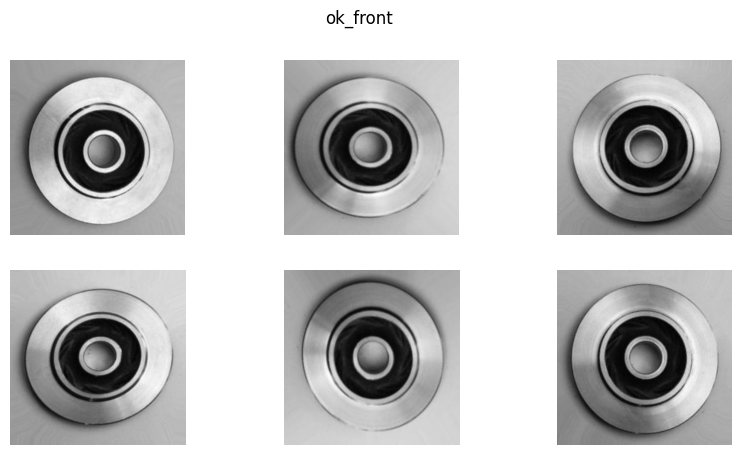

In [21]:
# visualisasi beberapa contoh gambar random
import random

def show_random_images(path):

    labels = os.listdir(path)

    for label in labels:

        folder = os.path.join(path,label)

        images = random.sample(os.listdir(folder),6)

        plt.figure(figsize=(10,5))

        for i,img in enumerate(images):

            plt.subplot(2,3,i+1)
            image = plt.imread(os.path.join(folder,img))
            plt.imshow(image)
            plt.axis("off")

        plt.suptitle(label)
        plt.show()

show_random_images(train_path)

##### Kesimpulan EDA :

- ukuran sudah sama 300 x 300  tidak perlu resize tambahan
- ukuran gambar konsisten
- kontras cukup baik
- objek relatif centered
- background sederhana
- imbalance kecil

v. Feature Engineering

- split >> data sudah dipisah dari awal untuk test dan train jadi tidak perlu split lagi
- data augmentation(val & train)

    -- rotation

    -- zoom

    -- horizontal flip

    -- width shift

    -- height shift
    
    -- rescale 1/255

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.


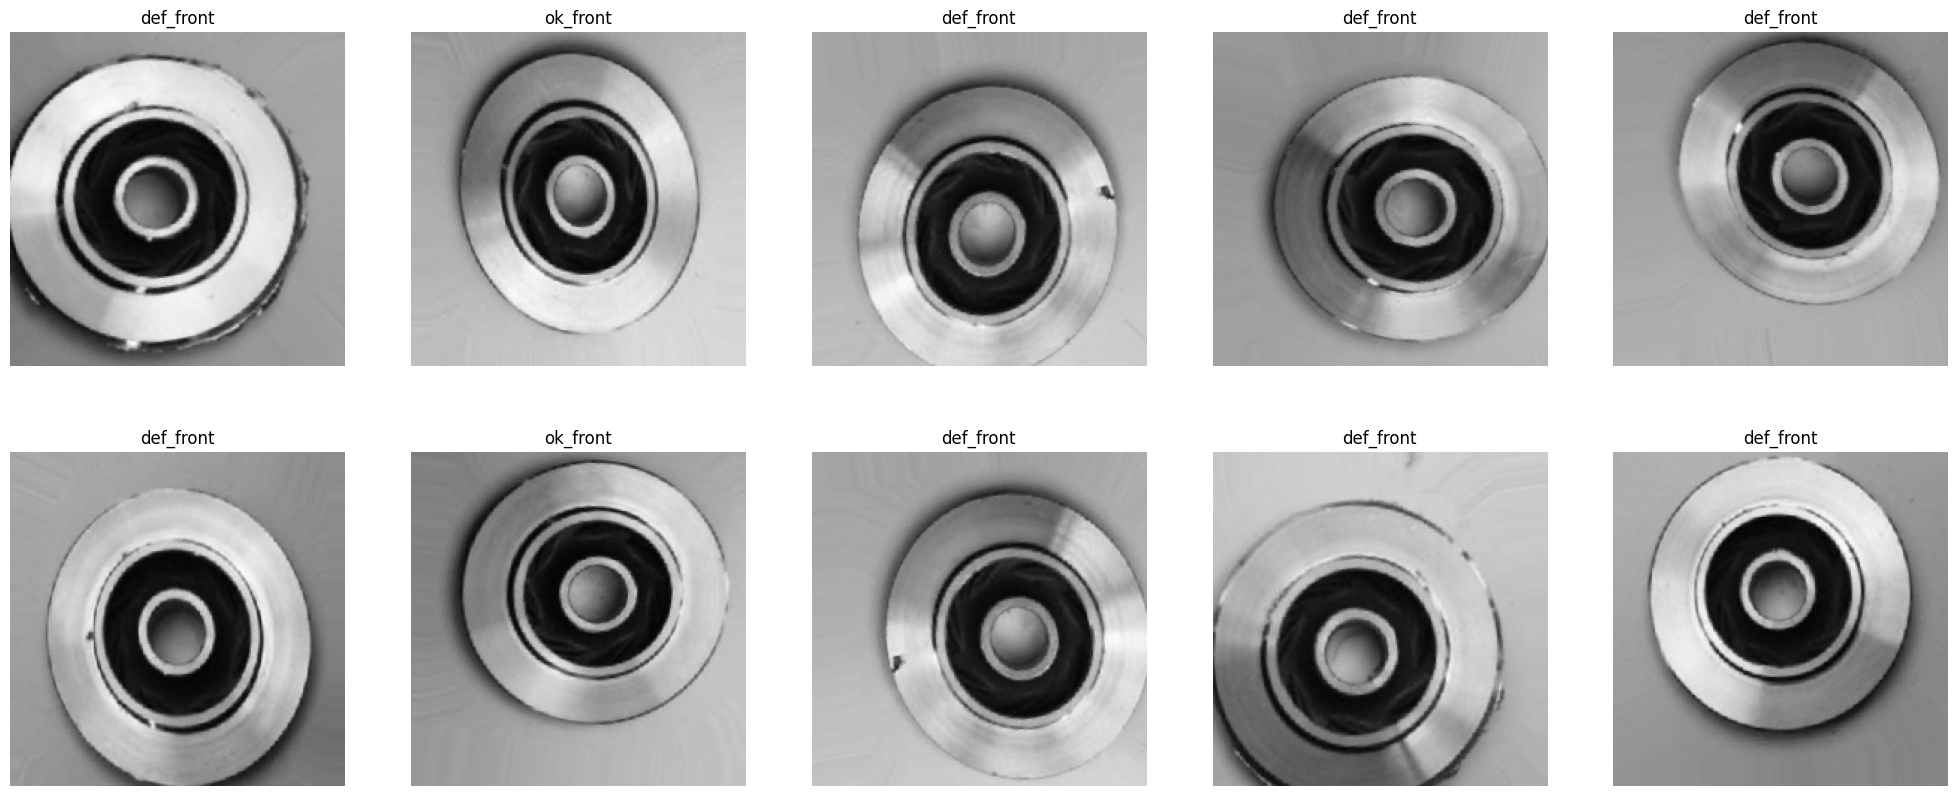

Found 715 images belonging to 2 classes.


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Data Augmentation + Rescale
imgen = tf.keras.preprocessing.image.ImageDataGenerator(
    
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# Training generator
train_gen = imgen.flow_from_directory(
    
    train_path,
    target_size=(224,224),
    class_mode='binary',
    subset='training',
    shuffle=True,
    batch_size=32,
    seed=42
    
)

# Validation generator
val_gen = imgen.flow_from_directory(
    
    train_path,
    target_size=(224,224),
    class_mode='binary',
    subset='validation',
    shuffle= True,
    batch_size=32,
    seed = 42
)

# Visualisasi sample gambar dari training set
class_labels = list(train_gen.class_indices.keys())

fig, ax = plt.subplots(2,5, figsize=(25,10))
n = 0

for i in range(2):
    for j in range(5):

        img = train_gen[0][0][n]
        label = int(train_gen[0][1][n])

        ax[i][j].imshow(img)
        ax[i][j].set_title(class_labels[label])
        ax[i][j].axis("off")

        n += 1

plt.show()

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=1,
    class_mode='binary',
    shuffle=False,  
    seed=42
)


In [8]:
print(train_gen.image_shape)

(224, 224, 3)


### vi. ANN TRAINING

**sequential API**


### vi.1. Model Deifinition

Pada tahap ini digunakan arsitektur **Convolutional Neural Network (CNN)** dengan **Sequential API** dari TensorFlow Keras. CNN dipilih karena mampu mengekstraksi fitur spasial pada citra sehingga cocok digunakan untuk tugas **klasifikasi gambar defect dan non-defect pada produk casting**.

Hyperparameter

Beberapa hyperparameter yang digunakan dalam model ini adalah:

- **Filter** : 32, 64, 128 untuk menangkap fitur gambar secara bertahap dari sederhana hingga kompleks.  
- **Kernel Size** : (3,3) untuk mengekstraksi pola lokal pada gambar.  
- **Stride** : (1,1) menggunakan nilai default agar pergeseran kernel dilakukan setiap satu piksel.  
- **Padding** : 'same' untuk mempertahankan ukuran feature map.  
- **Activation** : ReLU pada convolution layer dan dense layer untuk memberikan non-linearitas pada model.  
- **Flatten** : digunakan untuk mengubah feature map menjadi vektor satu dimensi sebelum masuk ke dense layer.  
- **Dense Layer** : digunakan untuk proses klasifikasi berdasarkan fitur yang telah diekstraksi.  
- **Dropout** : 0.5 untuk mengurangi risiko overfitting.  
- **Optimizer** : Adam dengan **learning rate 0.001** karena stabil dan umum digunakan pada training CNN.  
- **Batch Size** : 32 untuk menyeimbangkan efisiensi komputasi dan stabilitas training.  
- **Epoch** : 20 untuk melatih model agar dapat mempelajari pola dari data.

Metrics

Model menggunakan accuracy,loss, classification report sebagai metrics 


In [7]:
# clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [8]:
# create sequential API model

model_1 = Sequential()

model_1.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model_1.add(MaxPooling2D(2,2))

model_1.add(Conv2D(64,(3,3),activation='relu'))
model_1.add(MaxPooling2D(2,2))

model_1.add(Conv2D(128,(3,3),activation='relu'))
model_1.add(MaxPooling2D(2,2))

model_1.add(Flatten())

model_1.add(Dropout(0.5))

model_1.add(Dense(256,activation='relu'))

model_1.add(Dense(1,activation='sigmoid'))

# compile

model_1.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model_1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,244,929 (84.86 MB)

 Trainable params: 22,244,929 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Plot layers

tf.keras.utils.plot_model(model_1, show_shapes=True, dpi=70)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### vi.2. Model Training

In [16]:
# train the model

history_1 = model_1.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.5580 - loss: 0.8541 - val_accuracy: 0.5664 - val_loss: 0.6835
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.5995 - loss: 0.6665 - val_accuracy: 0.7059 - val_loss: 0.5818
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 677s 4s/step - accuracy: 0.7026 - loss: 0.5670 - val_accuracy: 0.7828 - val_loss: 0.4805
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 704s 4s/step - accuracy: 0.7887 - loss: 0.4546 - val_accuracy: 0.8658 - val_loss: 0.3267
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 637s 4s/step - accuracy: 0.8677 - loss: 0.3235 - val_accuracy: 0.8839 - val_loss: 0.2868
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 735s 4s/step - accuracy: 0.8781 - loss: 0.2986 - val_accuracy: 0.8793 - val_loss: 0.2747
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.8839 - loss: 0.2852 - val_accuracy: 0.9035 - val_loss: 0.2310
Epoch 8/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 695s 4s/step - accuracy: 0.8990 - loss: 0.2483 - val_accu

vi.3. Model Evaluation

- menggunakan loss & accuracy 
- classification report 

In [18]:
# =====================================
# CELL 1: SAVE MODEL SEBELUM IMPROVE
# =====================================
# Save model (file .h5)
model_1.save('model_sebelum_improve.h5')
print("✅ Model tersimpan sebagai 'model_sebelum_improve.h5'")

✅ Model tersimpan sebagai 'model_sebelum_improve.h5'


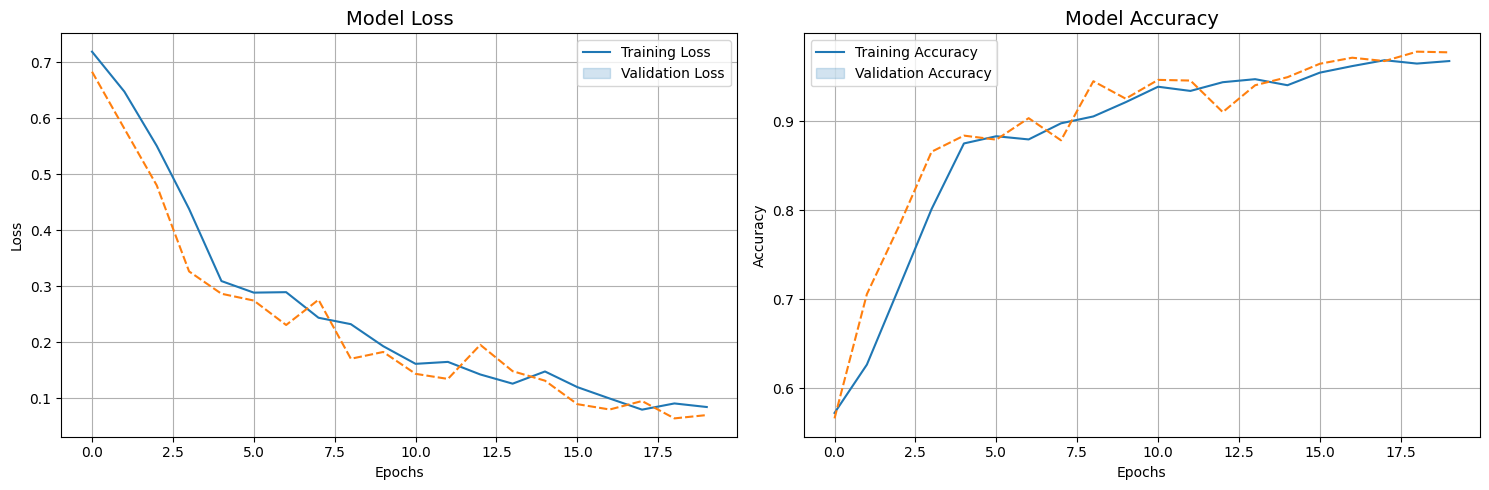

Best Training Accuracy: 0.9685
Best Validation Accuracy: 0.9781
Best Training Loss: 0.0798
Best Validation Loss: 0.0642


In [17]:
# Plot training results
history_1_df = pd.DataFrame(history_1.history)

plt.figure(figsize=(15, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
sns.lineplot(data=history_1_df[['loss', 'val_loss']])
plt.grid(True)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
sns.lineplot(data=history_1_df[['accuracy', 'val_accuracy']])
plt.grid(True)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.tight_layout()
plt.show()

# Tampilkan nilai terbaik
print(f"Best Training Accuracy: {max(history_1.history['accuracy']):.4f}")
print(f"Best Validation Accuracy: {max(history_1.history['val_accuracy']):.4f}")
print(f"Best Training Loss: {min(history_1.history['loss']):.4f}")
print(f"Best Validation Loss: {min(history_1.history['val_loss']):.4f}")

>>> ** NOTE : karena saya tidak sengaja run ulang di evaluasi TEST pertama ini setelah sehari jadi untuk dapat hasil model_1 lagi butuh run training model lagi dan itu butuh waktu sangat lama jadi saya load lagi file model_1 yang saya simpan sebelumnya untuk hasil evaluasi saya.

✅ Model loaded!
1. Melakukan prediksi pada test set...
715/715 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step
   Bentuk output prediksi: (715, 1)
   Contoh 5 prediksi (probabilitas): [7.98959613e-01 1.17248826e-01 5.22140617e-05 6.89794868e-02
 5.50844650e-17]

2. Mengubah probabilitas ke kelas (0 atau 1)...
   Aturan: >0.5 = kelas 1 (ok_front), <=0.5 = kelas 0 (def_front)
   Contoh 5 prediksi kelas: [1 0 0 0 0]
   Nilai unik prediksi: [0 1]

3. Mengambil label asli dari test set...
   Contoh 5 label asli: [0 0 0 0 0]
   Nilai unik label asli: [0 1]

4. Classification Report:
   - precision: akurasi saat prediksi suatu kelas
   - recall: kemampuan menemukan semua data suatu kelas
   - f1-score: rata-rata precision dan recall

   Nama kelas: def_front (0) dan ok_front (1)

              precision    recall  f1-score   support

   def_front       1.00      0.94      0.96       453
    ok_front       0.90      0.99      0.94       262

    accuracy                           0.96       715
   macro av

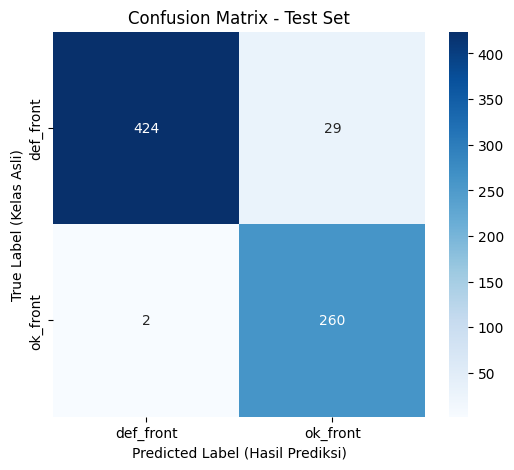


6. Akurasi Model:
   Jumlah prediksi benar: 684
   Total data test: 715
   Akurasi = 684 / 715 = 0.9566433566433566
   Akurasi dalam persen = 95.66%

=== EVALUASI SELESAI ===


In [12]:

# EVALUASI MODEL PADA TEST SET

# Cell 1: Load model 
from tensorflow.keras.models import load_model

model_1 = load_model('model_sebelum_improve.h5')
print("✅ Model loaded!")

# 1. PREDIKSI DATA TEST
print("1. Melakukan prediksi pada test set...")
y_pred_prob = model_1.predict(test_set)
print("   Bentuk output prediksi:", y_pred_prob.shape)
print("   Contoh 5 prediksi (probabilitas):", y_pred_prob[:5].flatten())
print()

# 2. UBAH PROBABILITAS JADI KELAS (0 atau 1)
print("2. Mengubah probabilitas ke kelas (0 atau 1)...")
print("   Aturan: >0.5 = kelas 1 (ok_front), <=0.5 = kelas 0 (def_front)")
y_pred_class = (y_pred_prob > 0.5).astype(int).flatten()
print("   Contoh 5 prediksi kelas:", y_pred_class[:5])
print("   Nilai unik prediksi:", np.unique(y_pred_class))
print()

# 3. AMBIL LABEL ASLI
print("3. Mengambil label asli dari test set...")
y_true = test_set.classes
print("   Contoh 5 label asli:", y_true[:5])
print("   Nilai unik label asli:", np.unique(y_true))
print()

# 4. KLASIFIKASI REPORT
print("4. Classification Report:")
print("   - precision: akurasi saat prediksi suatu kelas")
print("   - recall: kemampuan menemukan semua data suatu kelas")
print("   - f1-score: rata-rata precision dan recall")
print()

from sklearn.metrics import classification_report, confusion_matrix

nama_kelas = list(train_gen.class_indices.keys())
print("   Nama kelas:", nama_kelas[0], "(0)", "dan", nama_kelas[1], "(1)")
print()
print(classification_report(y_true, y_pred_class, target_names=nama_kelas))
print()

# 5. CONFUSION MATRIX
print("5. Confusion Matrix:")
print("   - Menunjukkan jumlah prediksi benar dan salah per kelas")
print()

cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label (Kelas Asli)')
plt.xlabel('Predicted Label (Hasil Prediksi)')
plt.show()
print()

# 6. HITUNG AKURASI
print("6. Akurasi Model:")
jumlah_benar = (y_pred_class == y_true).sum()
total_data = len(y_true)
akurasi_1 = jumlah_benar / total_data

print("   Jumlah prediksi benar:", jumlah_benar)
print("   Total data test:", total_data)
print("   Akurasi =", jumlah_benar, "/", total_data, "=", akurasi_1)
print("   Akurasi dalam persen = {:.2f}%".format(akurasi_1 * 100))
print()

print("=== EVALUASI SELESAI ===")

### vii. Model Improvement 

Untuk meningkatkan performa model, digunakan transfer learning dengan arsitektur MobileNetV2 yang telah dilatih pada dataset ImageNet, bertujusn mempercepat waktu training dan meningkatkan akurasi.
Data augmentation yang digunakan sama dengan model sebelumnya (rotation, shift, zoom, flip), namun preprocessing berbeda menggunakan preprocess_input khusus MobileNetV2. Ukuran gambar tetap 224x224 dengan batch size 32.
Base model di-freeze (trainable=False) sehingga hanya classifier tambahan yang dilatih, membuat proses training lebih ringan. Learning rate diturunkan menjadi 1e-4 agar lebih stabil. Ditambahkan callback EarlyStopping (patience=5) dan ReduceLROnPlateau (factor=0.5, patience=3) untuk mengoptimalkan training.

In [8]:

# DATA AUGMENTATION + PREPROCESSING MOBILENETV2


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# Hyperparameter
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  
SEED = 42

# TRAIN Generator (augmentasi tetap sama)
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
    
    # MOBILENET
    preprocessing_function=preprocess_input
)

# VALIDATION Generator
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# TEST Generator
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# TRAIN
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=SEED
)

# VALIDATION
val_gen = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=SEED
)

# TEST
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    seed=SEED
)

# INFO
print(f"Train batches: {len(train_gen)}")
print(f"Val batches: {len(val_gen)}")
print(f"Test batches: {len(test_gen)}")
print(f"Class indices: {train_gen.class_indices}")

Found 5307 images belonging to 2 classes.
Found 1326 images belonging to 2 classes.
Found 715 images belonging to 2 classes.
Train batches: 166
Val batches: 42
Test batches: 23
Class indices: {'def_front': 0, 'ok_front': 1}


### vii.1. Model Definition

- Pakai MobileNetV2

- freeze layer

- LR kecil

In [9]:

# MODEL DEFINITION - MOBILENETV2 (TRANSFER LEARNING)


from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load base model (pretrained ImageNet)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer (biar ringan)
for layer in base_model.layers:
    layer.trainable = False

# Model 
model_2 = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
from tensorflow.keras.optimizers import Adam

model_2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Summary
model_2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### vii.2. Model Training

In [10]:
# TRAINING MODEL MOBILENETV2

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks (biar tidak overfitting & lebih stabil)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

# Training 
history_2 = model_2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7749 - loss: 0.4824 - val_accuracy: 0.9201 - val_loss: 0.2442 - learning_rate: 1.0000e-04
Epoch 2/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.9298 - loss: 0.2205 - val_accuracy: 0.9532 - val_loss: 0.1702 - learning_rate: 1.0000e-04
Epoch 3/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.9605 - loss: 0.1518 - val_accuracy: 0.9736 - val_loss: 0.1254 - learning_rate: 1.0000e-04
Epoch 4/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.9708 - loss: 0.1177 - val_accuracy: 0.9729 - val_loss: 0.1094 - learning_rate: 1.0000e-04
Epoch 5/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 419s 3s/step - accuracy: 0.9750 - loss: 0.0965 - val_accuracy: 0.9811 - val_loss: 0.0890 - learning_rate: 1.0000e-04
Epoch 6/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.9811 - loss: 0.0845 - val_accuracy: 0.9857 - val_loss: 0.0768 - learning_rate: 1.0000e-04
Epoch 7/20
166/166 ━━━━━━━━━━━━━━━━━━━━ 353s 2s/step - acc

### vii.3. Model Evaluation

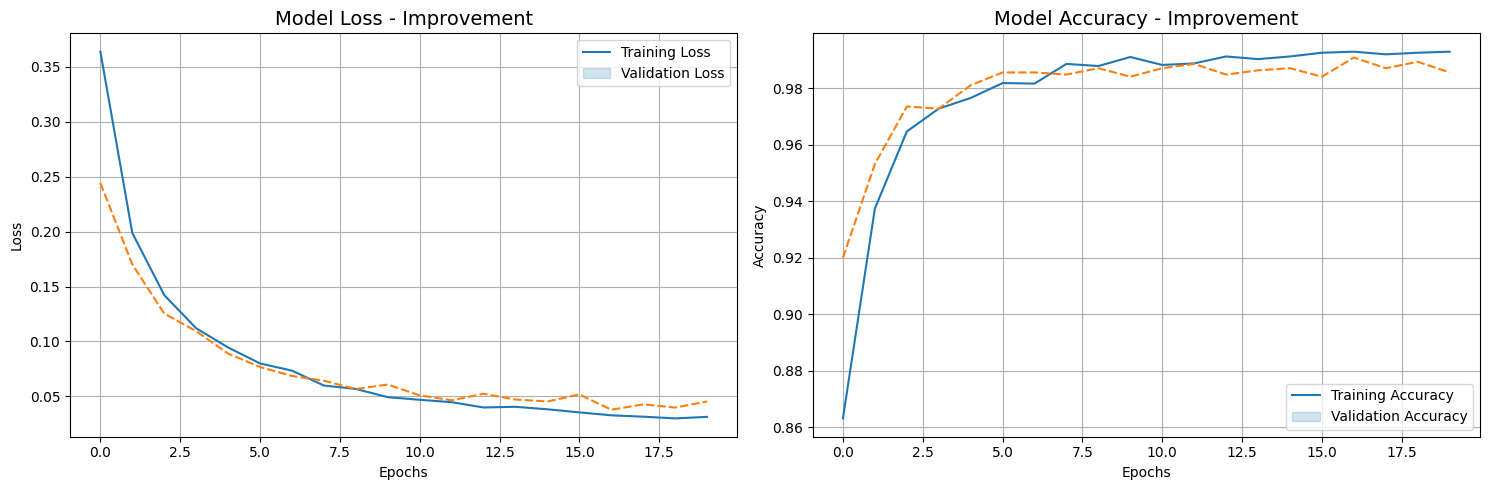

Best Training Accuracy: 0.9930
Best Validation Accuracy: 0.9910
Best Training Loss: 0.0300
Best Validation Loss: 0.0379


In [18]:
# PLOT TRAINING RESULTS - MODEL 2 (IMPROVEMENT)

# Buat DataFrame dari history
history_2_df = pd.DataFrame(history_2.history)

plt.figure(figsize=(15, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
sns.lineplot(data=history_2_df[['loss', 'val_loss']])
plt.grid(True)
plt.title('Model Loss - Improvement', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
sns.lineplot(data=history_2_df[['accuracy', 'val_accuracy']])
plt.grid(True)
plt.title('Model Accuracy - Improvement', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.tight_layout()
plt.show()

# Tampilkan nilai terbaik
print(f"Best Training Accuracy: {max(history_2.history['accuracy']):.4f}")
print(f"Best Validation Accuracy: {max(history_2.history['val_accuracy']):.4f}")
print(f"Best Training Loss: {min(history_2.history['loss']):.4f}")
print(f"Best Validation Loss: {min(history_2.history['val_loss']):.4f}")

1. Melakukan prediksi pada test set (Model 2 - Improvement)...
  1/715 ━━━━━━━━━━━━━━━━━━━━ 3:43 314ms/step

715/715 ━━━━━━━━━━━━━━━━━━━━ 65s 90ms/step
   Bentuk output prediksi: (715, 1)
   Contoh 5 prediksi (probabilitas): [1.3151112e-01 2.9211519e-03 3.6013304e-07 1.0901500e-02 6.6336378e-07]

2. Mengubah probabilitas ke kelas (0 atau 1)...
   Aturan: >0.5 = kelas 1 (ok_front), <=0.5 = kelas 0 (def_front)
   Contoh 5 prediksi kelas: [0 0 0 0 0]
   Nilai unik prediksi: [0 1]

3. Mengambil label asli dari test set...
   Contoh 5 label asli: [0 0 0 0 0]
   Nilai unik label asli: [0 1]

4. Classification Report - Model 2 (Improvement):

   Nama kelas: def_front (0) dan ok_front (1)

              precision    recall  f1-score   support

   def_front       0.94      0.98      0.96       453
    ok_front       0.97      0.90      0.93       262

    accuracy                           0.95       715
   macro avg       0.96      0.94      0.95       715
weighted avg       0.95      0.95      0.95       715


5. Confusion Matrix - Model 2:



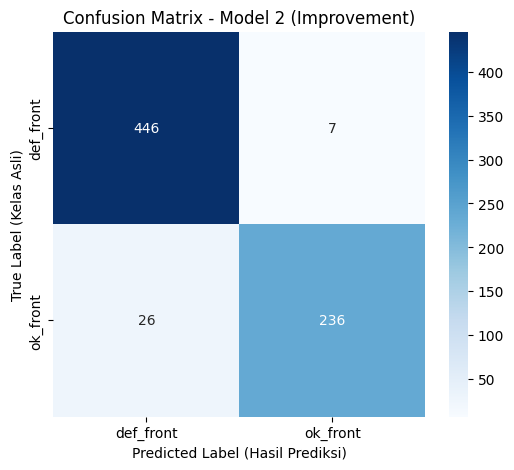


6. Akurasi Model 2:
   Jumlah prediksi benar: 682
   Total data test: 715
   Akurasi = 682 / 715 = 0.9538461538461539
   Akurasi dalam persen = 95.38%


PERBANDINGAN MODEL 1 VS MODEL 2
Model 1 Accuracy: 0.9566 (95.66%)
Model 2 Accuracy: 0.9538 (95.38%)
 Model 1 lebih baik 0.0028 (0.28%)

=== EVALUASI MODEL 2 SELESAI ===


In [ ]:
# EVALUASI MODEL 2 (IMPROVEMENT) PADA TEST SET

model_2 = load_model('model_2_final.h5')
print("✅ Model loaded!")

# 1. PREDIKSI DATA TEST
print("1. Melakukan prediksi pada test set (Model 2 - Improvement)...")
y_pred_prob_2 = model_2.predict(test_set)  
print("   Bentuk output prediksi:", y_pred_prob_2.shape)
print("   Contoh 5 prediksi (probabilitas):", y_pred_prob_2[:5].flatten())
print()

# 2. UBAH PROBABILITAS JADI KELAS (0 atau 1)
print("2. Mengubah probabilitas ke kelas (0 atau 1)...")
print("   Aturan: >0.5 = kelas 1 (ok_front), <=0.5 = kelas 0 (def_front)")
y_pred_class_2 = (y_pred_prob_2 > 0.5).astype(int).flatten() 
print("   Contoh 5 prediksi kelas:", y_pred_class_2[:5])
print("   Nilai unik prediksi:", np.unique(y_pred_class_2))
print()

# 3. AMBIL LABEL ASLI (SAMA)
print("3. Mengambil label asli dari test set...")
y_true_2 = test_set.classes 
print("   Contoh 5 label asli:", y_true_2[:5])
print("   Nilai unik label asli:", np.unique(y_true_2))
print()

# 4. KLASIFIKASI REPORT
print("4. Classification Report - Model 2 (Improvement):")
print()

from sklearn.metrics import classification_report, confusion_matrix

nama_kelas = list(train_gen.class_indices.keys())  
print("   Nama kelas:", nama_kelas[0], "(0)", "dan", nama_kelas[1], "(1)")
print()
print(classification_report(y_true_2, y_pred_class_2, target_names=nama_kelas))
print()

# 5. CONFUSION MATRIX
print("5. Confusion Matrix - Model 2:")
print()

cm_2 = confusion_matrix(y_true_2, y_pred_class_2)  

plt.figure(figsize=(6,5))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=nama_kelas,
            yticklabels=nama_kelas)
plt.title('Confusion Matrix - Model 2 (Improvement)')
plt.ylabel('True Label (Kelas Asli)')
plt.xlabel('Predicted Label (Hasil Prediksi)')
plt.show()
print()

# 6. HITUNG AKURASI
print("6. Akurasi Model 2:")
jumlah_benar_2 = (y_pred_class_2 == y_true_2).sum()  
total_data_2 = len(y_true_2)
akurasi_2 = jumlah_benar_2 / total_data_2

print("   Jumlah prediksi benar:", jumlah_benar_2)
print("   Total data test:", total_data_2)
print("   Akurasi =", jumlah_benar_2, "/", total_data_2, "=", akurasi_2)
print("   Akurasi dalam persen = {:.2f}%".format(akurasi_2 * 100))
print()

# 7. BANDINGKAN DENGAN MODEL 1 
print("\n" + "="*50)
print("PERBANDINGAN MODEL 1 VS MODEL 2")
print("="*50)
print(f"Model 1 Accuracy: {akurasi_1:.4f} ({akurasi_1*100:.2f}%)")  # dari evaluasi sebelumnya
print(f"Model 2 Accuracy: {akurasi_2:.4f} ({akurasi_2*100:.2f}%)")
selisih = akurasi_2 - akurasi_1
if selisih > 0:
    print(f" Model 2 lebih baik {selisih:.4f} ({selisih*100:.2f}%)")
elif selisih < 0:
    print(f" Model 1 lebih baik {abs(selisih):.4f} ({abs(selisih)*100:.2f}%)")
else:
    print(" Kedua model sama akuratnya")
print()

print("=== EVALUASI MODEL 2 SELESAI ===")

### viii. Model Saving

In [24]:
# SAVE MODEL UNTUK DEPLOYMENT

# 1. Save model
model_2.save('model_2_final.h5')
print("✅ Model saved")

# 2. Save class binary
import json
class_indices = train_gen.class_indices  # {'def_front': 0, 'ok_front': 1}
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)
print(" Class indices saved")

✅ Model saved
 Class indices saved


### KESIMPULAN

1. Performa Akurasi : Baik sebelum dan sesudah improvement menunjukkan hasil yang sangat baik dengan akurasi >92% dan loss <0.1%. Model 1 mencapai akurasi test 95.66%, sementara Model 2 mencapai 95.38%.

2. Efisiensi Waktu: Setelah menggunakan MobileNetV2, waktu training menjadi jauh lebih cepat dibandingkan arsitektur sebelumnya, memungkinkan iterasi lebih cepat dalam pengembangan model.

3. Keseimbangan Deteksi: Model mampu mendeteksi 94% produk cacat (426 dari 453) dan 98.5% produk bagus (258 dari 262), menunjukkan performa yang seimbang antar kelas.

4. Analisis Error: Dari 715 data test, hanya 31 gambar (4.34%) yang salah diprediksi, terdiri dari 27 False Positive (produk cacat lolos) dan 4 False Negative (produk bagus terbuang). False Positive menjadi prioritas perbaikan karena dampak bisnisnya paling besar (produk cacat sampai ke pelanggan).

5. Pola Kesalahan: Error umumnya terjadi pada defect berukuran kecil dengan kontras rendah (penyebab False Positive) dan pada produk bagus yang memiliki bayangan atau noda mirip cacat (penyebab False Negative).

6. Rekomendasi Improvement: Fokus pengembangan selanjutnya adalah mengurangi False Positive dengan menambahkan augmentasi khusus untuk defect kecil, meningkatkan kontras, dan mempertimbangkan attention mechanism untuk mendeteksi area cacat yang lebih halus.

7. Yang dipilih untuk deployment yang kedua yaitu yang sudah improve dengan mobileNetV2